# 2.5 — Biais, variance, validation croisée et courbe ROC

**Navigation** : [<< 2.4-Arbres-Forets-Ensembles](2.4-Arbres-Forets-Ensembles.ipynb) | [2.6-Clustering-KMeans-PCA >>](2.6-Clustering-KMeans-PCA.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Les notebooks précédents (2.1 et 2.4) ont rendu le **surapprentissage** visible : un arbre profond affiche une accuracy d'entraînement proche de 1.0 tandis que son score de test s'effondre, et les méthodes d'ensemble (2.4) réduisent cet écart. Ce phénomène n'est pas un bug : c'est la manifestation concrète d'un compromis fondamental, le **compromis biais-variance**. Nous le formalisons ici, puis nous outillons pour le maîtriser : la **validation croisée** donne une estimation fiable de la performance (au lieu d'un seul découpage aléatoire source de bruit), et la **courbe ROC** avec l'**AUC** évaluent un classifieur au-delà de la seule accuracy, en exposant la structure des erreurs (faux positifs vs faux négatifs).

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Décomposer l'erreur de généralisation en **biais** et **variance** et reconnaître chaque régime (sous- et sur-apprentissage).
2. Utiliser la **validation croisée k-fold** pour obtenir une estimation fiable des performances, plutôt qu'un seul découpage entraînement/test.
3. Lire une **courbe ROC** et interpréter l'**AUC** comme métrique indépendante du seuil de décision.
4. Choisir un **seuil de décision** adapté au coût relatif des faux positifs et des faux négatifs.

### Prérequis

- Notebook 2.1 (surapprentissage rendu visible, train/test split, métriques).
- Notebook 2.3 (régression logistique, sigmoïde).
- Notebook 2.4 (arbres, forêts aléatoires, réduction de variance par ensembles).

> **Référence.** Geman, S., Bienenstock, É. & Doursat, R. (1992), *Neural Networks and the Bias/Variance Dilemma*, Neural Computation 4(1):1-58. La décomposition biais-variance formalise l'arbitrage fondamental : un modèle trop simple a un biais élevé (sous-apprentissage), un modèle trop complexe a une variance élevée (surapprentissage).

In [1]:
# Configuration et imports pour le notebook 2.5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix

np.random.seed(42)
print("Configuration OK : 2.5 - Biais, variance, validation croisee et ROC")

Configuration OK : 2.5 - Biais, variance, validation croisee et ROC


## 1. Le compromis biais-variance

L'erreur de généralisation d'un modèle se décompose en trois termes :

$$\text{Erreur} = \underbrace{\text{Biais}^2}_{\text{erreur systématique}} + \underbrace{\text{Variance}}_{\text{sensibilité à l'échantillon}} + \underbrace{\text{bruit irréductible}}_{\text{non modélisable}}$$

- Le **biais** mesure l'erreur systématique d'un modèle trop rigide : une régression linéaire appliquée à des données non-linéaires **sous-apprend** (*underfitting*). Ses prédictions sont cohérentes d'un échantillon à l'autre, mais systématiquement à côté.
- La **variance** mesure la sensibilité du modèle à l'échantillon d'entraînement : un arbre très profond **mémorise** les données (*overfitting*). Changez quelques lignes du jeu d'entraînement et sa frontière de décision change du tout au tout.

On ne peut pas minimiser les deux simultanément avec une seule complexité de modèle : c'est le **dilemme** de Geman et al. (1992). Image mentale : une **règle rigide** (biais élevé, variance faible) face à une **nouille flexible** (biais faible, variance élevée). La bonne complexité se trouve entre les deux — et la validation croisée (section 3) sert justement à la repérer.

In [2]:
# Chargement du jeu de donnees breast_cancer (classification binaire)
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Decoupage entraînement/test stratifie (meme proportion de classes dans chaque sous-ensemble)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Dimensions X : {X.shape} | nombre de variables : {X.shape[1]}")
print(f"Entraînement : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Classes (0 = malin, 1 = benin) dans y : {np.bincount(y)}")

Dimensions X : (569, 30) | nombre de variables : 30
Entraînement : 398 lignes | Test : 171 lignes
Classes (0 = malin, 1 = benin) dans y : [212 357]


## 2. Comparer plusieurs modèles (biais vs variance en pratique)

Comparons trois modèles de complexité croissante sur le **même** découpage entraînement/test :

- **Régression logistique** : frontière linéaire → biais potentiellement élevé, variance faible.
- **Forêt aléatoire** : moyenne de nombreux arbres → variance réduite (cf. notebook 2.4).
- **Arbre de décision profond** : un seul arbre non limité → variance élevée, mémorisation de l'entraînement.

Attention : la comparaison ci-dessous repose sur un **unique découpage**. Or la performance mesurée sur un seul ensemble de test est **bruitée** — elle dépend de quelles lignes sont tombées dans le test. La section 3 (validation croisée) corrigera ce défaut.

In [3]:
# Ajustement de 3 modeles et comparaison train vs test
# L'ecart (train - test) revele la variance : un modele qui memorise a train proche de 1.0
# mais un test nettement plus bas.
modeles = [
    ("Regression logistique", LogisticRegression(max_iter=1000)),
    ("Foret aleatoire", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Arbre profond", DecisionTreeClassifier(random_state=42)),
]

print(f"{'Modele':22s} | {'train':>7s} | {'test':>7s} | {'ecart':>7s}")
print("-" * 55)
for nom, modele in modeles:
    modele.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, modele.predict(X_train))
    acc_test = accuracy_score(y_test, modele.predict(X_test))
    print(f"{nom:22s} | {acc_train:7.3f} | {acc_test:7.3f} | {acc_train - acc_test:7.3f}")

Modele                 |   train |    test |   ecart
-------------------------------------------------------


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regression logistique  |   0.967 |   0.942 |   0.026


Foret aleatoire        |   1.000 |   0.936 |   0.064
Arbre profond          |   1.000 |   0.918 |   0.082


### Exercice 1 : identifier le modèle à plus forte variance

À partir du tableau affiché ci-dessus (ou en recalculant), repérez quel modèle présente le **plus grand écart** entre accuracy d'entraînement et accuracy de test. Ce gap `train - test` est l'indice le plus direct d'une variance élevée : le modèle ajuste trop finement l'échantillon d'entraînement pour bien généraliser.

Indices :
- # Etape 1 : pour chaque `(nom, modele)` dans `modeles`, recalculer `acc_train` et `acc_test` (comme dans la cellule précédente).
- # Etape 2 : former la liste `ecarts` des différences `acc_train - acc_test`.
- # Etape 3 : récupérer l'indice du maximum avec `np.argmax(ecarts)`, puis `modeles[indice_max][0]` pour le nom.

In [4]:
# Exercice 1 : trouver le modele avec le plus grand ecart train-test (variance la plus elevee)
# TODO etudiant : pour chaque modele dans modeles, calculer l'ecart (train_acc - test_acc)
ecarts = None  # TODO etudiant : remplacer (liste des ecarts train-test pour chaque modele)
# TODO etudiant : indice du modele avec le plus grand ecart
indice_max = None  # TODO etudiant : remplacer (np.argmax(ecarts))
nom_max_variance = None  # TODO etudiant : remplacer (modeles[indice_max][0])
print(f"Exercice 1 a completer : modele a plus forte variance = {nom_max_variance}")

Exercice 1 a completer : modele a plus forte variance = None


## 3. Validation croisée k-fold

Un seul découpage entraînement/test donne une estimation **bruitée** de la performance : deux `random_state` différents produisent des scores différents. La **validation croisée k-fold** réduit cette incertitude en découpant les données en *k* plis de taille égale, puis en entraînant sur *k-1* plis et en testant sur le pli restant, en faisant tourner les rôles. On obtient ainsi *k* scores, dont la **moyenne ± l'écart-type** est une estimation bien plus fiable.

Notez bien la nuance : la validation croisée traite la variance de l'**évaluation** (l'incertitude sur le score mesuré), qui est distincte de la variance du **modèle** (section 1). Les deux se combinent, mais on les combat différemment.

> **Référence.** Stone, M. (1974), *Cross-Validatory Choice and Assessment of Statistical Predictions*, Journal of the Royal Statistical Society. Series B (Methodological) 36(2):111-147. La validation croisée y est posée comme la méthode de référence pour estimer l'erreur de généralisation sans sacrifier de données à un unique ensemble de test.

In [5]:
# Validation croisee 5-fold de la regression logistique sur l'ensemble des donnees
scores_cv = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5)

print("Scores par fold :", np.round(scores_cv, 3))
print(f"Moyenne : {scores_cv.mean():.3f}")
print(f"Ecart-type : {scores_cv.std():.3f}")

C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scores par fold : [0.939 0.939 0.974 0.947 0.965]
Moyenne : 0.953
Ecart-type : 0.014


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Comparer les modèles par validation croisée

Évaluons maintenant les **trois** modèles par validation croisée 5-fold sur l'ensemble des données, et comparons les scores moyens (avec l'écart-type comme barre d'incertitude). C'est la démarche **principielle** pour choisir un modèle : non pas un seul découpage arbitraire, mais une estimation accompagnée de son incertitude.

In [6]:
# Comparaison des 3 modeles par validation croisee
print(f"{'Modele':22s} | {'moyenne':>9s} | {'ecart-type':>10s}")
print("-" * 50)
for nom, modele in modeles:
    sc = cross_val_score(modele, X, y, cv=5)
    print(f"{nom:22s} | {sc.mean():9.3f} | {sc.std():10.3f}")

Modele                 |   moyenne | ecart-type
--------------------------------------------------


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regression logistique  |     0.953 |      0.014


Foret aleatoire        |     0.956 |      0.023
Arbre profond          |     0.917 |      0.024


### Exercice 2 : le nombre de folds

Le choix de *k* n'est pas anodin. Recalculez le score de validation croisée de la régression logistique avec **`cv=10`** au lieu de 5 et comparez la moyenne à celle de `scores_cv` (cv=5, cellule précédente). Un *k* plus grand utilise davantage de données pour l'entraînement (plis de test plus petits) : la moyenne a tendance à être légèrement optimiste, mais le coût de calcul augmente.

Indices :
- # Etape 1 : appeler `cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=10)`.
- # Etape 2 : stocker le résultat dans `scores_cv10` puis `moyenne_cv10 = np.mean(scores_cv10)`.
- # Etape 3 : comparer à `scores_cv.mean()` (cv=5).

In [7]:
# Exercice 2 : recalculer le score CV de la regression logistique avec cv=10
# TODO etudiant : cross_val_score avec cv=10 sur la regression logistique (X, y)
scores_cv10 = None  # TODO etudiant : remplacer
# TODO etudiant : comparer la moyenne a celle de scores_cv (cv=5)
moyenne_cv10 = None  # TODO etudiant : remplacer (np.mean(scores_cv10))
print(f"Exercice 2 a completer : moyenne cv=10 = {moyenne_cv10}")

Exercice 2 a completer : moyenne cv=10 = None


## 5. Au-delà de l'accuracy : faux positifs et faux négatifs

L'accuracy globale masque le **type** d'erreurs commises. Or dans un diagnostic de cancer du sein, un **faux négatif** (manquer une tumeur maligne) est bien plus coûteux qu'un faux positif (faire passer un examen complémentaire à un patient sain). Nous avons besoin de la **matrice de confusion** et de la **courbe ROC** pour voir la structure des erreurs, pas seulement leur nombre agrégé.

C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


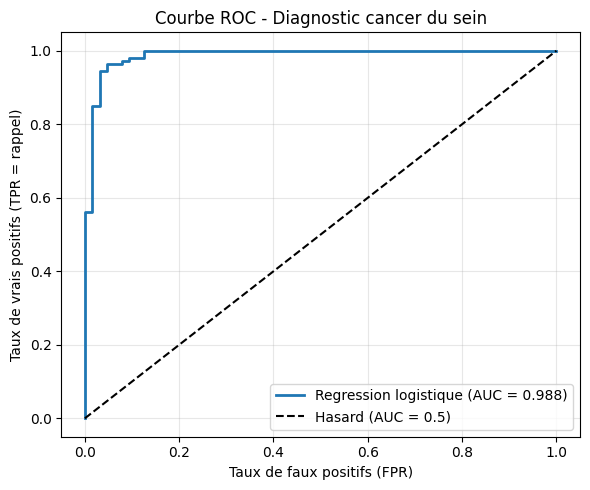

In [8]:
# Courbe ROC et AUC de la regression logistique sur l'ensemble de test
meilleur_modele = LogisticRegression(max_iter=1000)
meilleur_modele.fit(X_train, y_train)

# Probabilites predites pour la classe 1 (benin)
proba_test = meilleur_modele.predict_proba(X_test)[:, 1]

# Courbe ROC et AUC
fpr, tpr, seuils = roc_curve(y_test, proba_test)
auc_score = roc_auc_score(y_test, proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Regression logistique (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR = rappel)")
plt.title("Courbe ROC - Diagnostic cancer du sein")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. La courbe ROC et l'AUC

La courbe **ROC** (*Receiver Operating Characteristic*) trace le **TPR** (taux de vrais positifs, c'est-à-dire le rappel) en fonction du **FPR** (taux de faux positifs) pour **tous** les seuils de décision possibles. Plus la courbe se rapproche du coin supérieur gauche, meilleur est le classifieur. La diagonale correspond à un classifieur aléatoire (AUC = 0.5).

L'**AUC** (aire sous la courbe) se lit comme la **probabilité que le modèle classe un exemple positif au-dessus d'un exemple négatif** tirés au hasard. Elle est **indépendante du seuil** de décision, contrairement à l'accuracy : c'est ce qui en fait une métrique équitable pour comparer deux classifieurs dont les seuils par défaut pourraient différer.

> **Référence.** Bradley, A.P. (1997), *The Use of the Area Under the ROC Curve in the Evaluation of Machine Learning Algorithms*, Pattern Recognition 30(6):1145-1159. L'AUC (aire sous la courbe ROC) y est établie comme métrique robuste, indépendante du seuil de décision, pour comparer des classifieurs.

In [9]:
# Exercice 3 : interpreter l'AUC
# TODO etudiant : l'AUC mesure la probabilite que le modele classe un positif au-dessus d'un negatif
# TODO etudiant : reprendre auc_score (cellule precedente) et le comparer a 0.5 (hasard)
verdict_auc = None  # TODO etudiant : remplacer par une chaine, ex "excellent (>0.9)" ou "correct (0.7-0.9)" ou "faible (<0.7)"
print(f"Exercice 3 a completer : AUC = {auc_score:.3f} => {verdict_auc}")

Exercice 3 a completer : AUC = 0.988 => None


## 7. Choisir un seuil de décision

Par défaut, un classifieur comme la régression logistique prédit la classe 1 dès que la probabilité estimée dépasse **0.5**. Ce seuil n'a rien de magique. En médecine, on peut vouloir le **baisser** (ex. 0.3) pour rattraper davantage de cas positifs, quitte à déclencher plus de fausses alarmes ; ou au contraire le **monter** si le coût d'un faux positif est élevé. Se déplacer le long de la courbe ROC, c'est exactement **échanger du TPR contre du FPR**. Le bon point de fonctionnement dépend du coût relatif des erreurs.

In [10]:
# Matrices de confusion a deux seuils differents pour le meme modele
proba = meilleur_modele.predict_proba(X_test)[:, 1]
pred_05 = (proba >= 0.5).astype(int)
pred_03 = (proba >= 0.3).astype(int)

print("Seuil = 0.5 (par defaut)")
print(confusion_matrix(y_test, pred_05))
print("\nSeuil = 0.3 (plus sensible aux positifs)")
print(confusion_matrix(y_test, pred_03))
print("\nInterpretation : la matrice de confusion s'organise en")
print("[[vrais negatifs, faux positifs], [faux negatifs, vrais positifs]].")
print("Un seuil plus bas reduit les faux negatifs mais augmente les faux positifs :")
print("c'est exactement le compromis decrit par la courbe ROC.")

Seuil = 0.5 (par defaut)
[[ 56   8]
 [  2 105]]

Seuil = 0.3 (plus sensible aux positifs)
[[ 56   8]
 [  0 107]]

Interpretation : la matrice de confusion s'organise en
[[vrais negatifs, faux positifs], [faux negatifs, vrais positifs]].
Un seuil plus bas reduit les faux negatifs mais augmente les faux positifs :
c'est exactement le compromis decrit par la courbe ROC.


## 8. Synthèse : quel modèle, quelle métrique ?

Trois leçons à retenir :

1. **Biais vs variance** : un modèle trop simple sous-apprend (biais élevé), un modèle trop complexe surapprend (variance élevée). La bonne complexité minimise l'erreur de généralisation, pas l'erreur d'entraînement.
2. **Estimation fiable** : la validation croisée k-fold remplace le découpage unique par une moyenne ± écart-type, quantifiant l'incertitude de l'évaluation.
3. **Choix de métrique** : l'accuracy suffit sur des données équilibrées et des coûts symétriques. Dès qu'une classe est rare ou qu'un type d'erreur coûte plus cher, on passe à l'**AUC** (seuil-indépendant) et on **choisit son seuil** selon le coût des faux positifs / faux négatifs.

C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


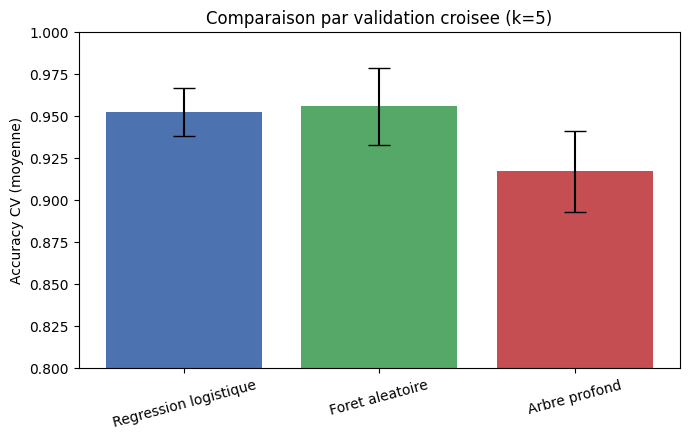

In [11]:
# Synthese visuelle : scores CV (moyenne +/- ecart-type) des 3 modeles
noms = []
moyennes = []
ecarts_types = []
for nom, modele in modeles:
    sc = cross_val_score(modele, X, y, cv=5)
    noms.append(nom)
    moyennes.append(sc.mean())
    ecarts_types.append(sc.std())

plt.figure(figsize=(7, 4.5))
plt.bar(range(len(noms)), moyennes, yerr=ecarts_types, capsize=8,
        color=["#4c72b0", "#55a868", "#c44e52"])
plt.xticks(range(len(noms)), noms, rotation=15)
plt.ylabel("Accuracy CV (moyenne)")
plt.title("Comparaison par validation croisee (k=5)")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

## Conclusion et transition

Nous avons formalisé le **compromis biais-variance** entrevu empiriquement en 2.1 et 2.4, puis outillé son évaluation : la **validation croisée k-fold** pour une estimation fiable (moyenne ± écart-type plutôt qu'un seul découpage bruité), et la **courbe ROC** avec l'**AUC** pour juger un classifieur au-delà de l'accuracy et choisir un **seuil de décision** adapté au coût des erreurs.

Le dernier notebook de la série (`2.6-Clustering-KMeans-PCA`) quitte l'apprentissage supervisé pour l'apprentissage **non supervisé** : clustering (**KMeans**) et réduction de dimension (**PCA**), sans étiquettes.

## References

1. Geman, S., Bienenstock, É. & Doursat, R. (1992). *Neural Networks and the Bias/Variance Dilemma*. Neural Computation 4(1):1-58. — Décomposition biais-variance, l'arbitrage fondamental.
2. Stone, M. (1974). *Cross-Validatory Choice and Assessment of Statistical Predictions*. Journal of the Royal Statistical Society. Series B 36(2):111-147. — La validation croisée comme estimation fiable de l'erreur de généralisation.
3. Bradley, A.P. (1997). *The Use of the Area Under the ROC Curve in the Evaluation of Machine Learning Algorithms*. Pattern Recognition 30(6):1145-1159. — L'AUC, métrique seuil-indépendante pour comparer des classifieurs.
4. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §7.10-7.11. — Validation croisée et compromis biais-variance.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `cross_val_score`, `roc_curve`, `roc_auc_score`, `confusion_matrix`.